# Day 13 — Enhancement / Detection Preparation
## Objective
To implement the classical underwater image-enhancement baseline, prepare Dataset V1 for YOLO object detection, and define the experimental comparison between original and enhanced images.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
DATASET_V1="/content/drive/MyDrive/Dataset_V1"
DATASETS=[
    "DIATAquarium.v4i.yolov8",
    "Aquatic Plant.v2i.yolov8",
    "well.v8i.yolov8"
]
print("Dataset V1 exists:",os.path.exists(DATASET_V1))
for dataset in DATASETS:
    path=os.path.join(DATASET_V1,dataset)
    print(dataset,"->",os.path.exists(path))

Dataset V1 exists: True
DIATAquarium.v4i.yolov8 -> True
Aquatic Plant.v2i.yolov8 -> True
well.v8i.yolov8 -> True


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
def white_balance(img):
    result=cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
    l,a,b=cv2.split(result)
    avg_a=np.mean(a)
    avg_b=np.mean(b)
    a=np.clip(a-(avg_a-128)*l/255,0,255).astype(np.uint8)
    b=np.clip(b-(avg_b-128)*l/255,0,255).astype(np.uint8)
    result=cv2.merge((l,a,b))
    return cv2.cvtColor(result,cv2.COLOR_LAB2BGR)

def apply_clahe(img):
    lab=cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
    l,a,b=cv2.split(lab)
    clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    l=clahe.apply(l)
    enhanced=cv2.merge((l,a,b))
    return cv2.cvtColor(enhanced,cv2.COLOR_LAB2BGR)

def enhance_image(img):
    img=white_balance(img)
    img=apply_clahe(img)
    return img

print("White Balance + CLAHE functions created successfully.")

White Balance + CLAHE functions created successfully.


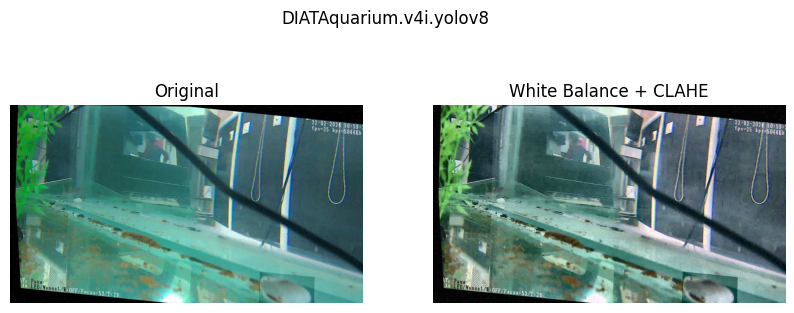

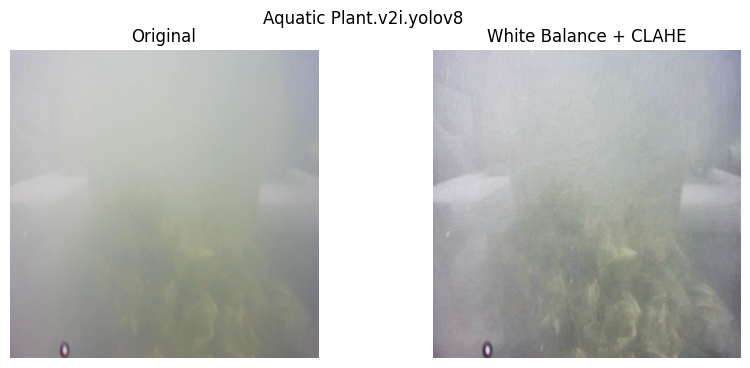

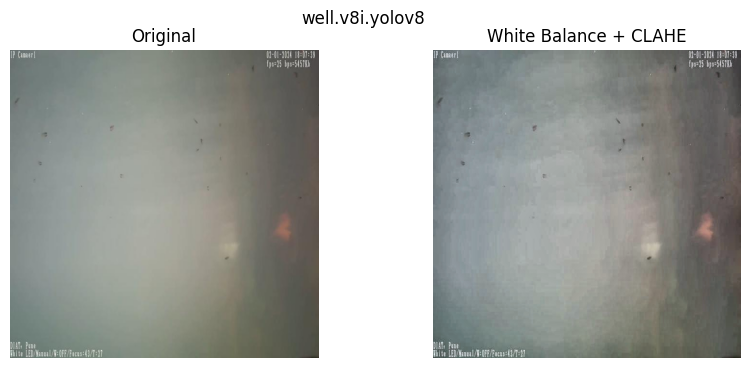

In [4]:
for dataset in DATASETS:
    image_dir=os.path.join(DATASET_V1,dataset,"train","images")
    files=[f for f in os.listdir(image_dir)
           if f.lower().endswith((".jpg",".jpeg",".png"))]
    file=files[0]
    image_path=os.path.join(image_dir,file)
    original=cv2.imread(image_path)
    enhanced=enhance_image(original)
    original_rgb=cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
    enhanced_rgb=cv2.cvtColor(enhanced,cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(enhanced_rgb)
    plt.title("White Balance + CLAHE")
    plt.axis("off")
    plt.suptitle(dataset)
    plt.show()

In [5]:
import os
ENHANCED_DIR="/content/drive/MyDrive/Dataset_V1_Enhanced"
for dataset in DATASETS:
    train_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")
    os.makedirs(train_dir,exist_ok=True)
print("Enhanced dataset folders created.")

Enhanced dataset folders created.


In [6]:
import os
import cv2
for dataset in DATASETS:
    input_dir=os.path.join(DATASET_V1,dataset,"train","images")
    output_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")
    os.makedirs(output_dir,exist_ok=True)
    files=[f for f in os.listdir(input_dir)
           if f.lower().endswith((".jpg",".jpeg",".png"))]
    print("\nDataset:",dataset)
    print("Total images:",len(files))
    for i,file in enumerate(files):
        input_path=os.path.join(input_dir,file)
        output_path=os.path.join(output_dir,file)
        image=cv2.imread(input_path)
        if image is None:
            print("Could not read:",file)
            continue
        enhanced=enhance_image(image)
        cv2.imwrite(output_path,enhanced)
        if (i+1)%500==0:
            print("Processed:",i+1)
    print("Completed:",dataset)
print("\nAll training images enhanced successfully.")


Dataset: DIATAquarium.v4i.yolov8
Total images: 8121
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
Processed: 5500
Processed: 6000
Processed: 6500
Processed: 7000
Processed: 7500
Processed: 8000
Completed: DIATAquarium.v4i.yolov8

Dataset: Aquatic Plant.v2i.yolov8
Total images: 1892
Processed: 500
Processed: 1000
Processed: 1500
Completed: Aquatic Plant.v2i.yolov8

Dataset: well.v8i.yolov8
Total images: 3795
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Completed: well.v8i.yolov8

All training images enhanced successfully.


In [7]:
import os
for dataset in DATASETS:
    original_dir=os.path.join(DATASET_V1,dataset,"train","images")
    enhanced_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")

    original_files=[f for f in os.listdir(original_dir)
                    if f.lower().endswith((".jpg",".jpeg",".png"))]

    enhanced_files=[f for f in os.listdir(enhanced_dir)
                    if f.lower().endswith((".jpg",".jpeg",".png"))]

    print("\nDataset:",dataset)
    print("Original training images:",len(original_files))
    print("Enhanced training images:",len(enhanced_files))
    print("Same number:",len(original_files)==len(enhanced_files))


Dataset: DIATAquarium.v4i.yolov8
Original training images: 8121
Enhanced training images: 8121
Same number: True

Dataset: Aquatic Plant.v2i.yolov8
Original training images: 1892
Enhanced training images: 1892
Same number: True

Dataset: well.v8i.yolov8
Original training images: 3795
Enhanced training images: 3795
Same number: True


In [8]:
for dataset in DATASETS:
    original_dir=os.path.join(DATASET_V1,dataset,"train","images")
    enhanced_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")
    original_files=set(
        f for f in os.listdir(original_dir)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    )
    enhanced_files=set(
        f for f in os.listdir(enhanced_dir)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    )
    missing_enhanced=original_files-enhanced_files
    extra_enhanced=enhanced_files-original_files
    print("\nDataset:",dataset)
    print("Missing enhanced images:",len(missing_enhanced))
    print("Extra enhanced images:",len(extra_enhanced))
    print("Filename matching:",len(missing_enhanced)==0 and len(extra_enhanced)==0)


Dataset: DIATAquarium.v4i.yolov8
Missing enhanced images: 0
Extra enhanced images: 0
Filename matching: True

Dataset: Aquatic Plant.v2i.yolov8
Missing enhanced images: 0
Extra enhanced images: 0
Filename matching: True

Dataset: well.v8i.yolov8
Missing enhanced images: 0
Extra enhanced images: 0
Filename matching: True


In [9]:
for dataset in DATASETS:
    yaml_path=os.path.join(DATASET_V1,dataset,"data.yaml")

    print("\n_____________________________________")
    print("Dataset:",dataset)
    print("_____________________________________")

    if os.path.exists(yaml_path):
        with open(yaml_path,"r") as f:
            print(f.read())
    else:
        print("data.yaml not found")


_____________________________________
Dataset: DIATAquarium.v4i.yolov8
_____________________________________
train: C:\Users\System2\PycharmProjects\yolov8\DIATAquarium.v4i.yolov8\train\images
val: C:\Users\System2\PycharmProjects\yolov8\DIATAquarium.v4i.yolov8\test\images
test: C:\Users\System2\PycharmProjects\yolov8\DIATAquarium.v4i.yolov8\test\images

nc: 11
names: ['Aquatic Plant', 'Camera', 'Conch-Shell', 'Fish', 'Fishes', 'Pluco', 'Shark', 'Temperature Sensor', 'Water-Pump', 'Water-filter', 'betta']

roboflow:
  workspace: nitesh-kumar-msuiq
  project: diat-aquarium
  version: 4
  license: CC BY 4.0
  url: https://universe.roboflow.com/nitesh-kumar-msuiq/diat-aquarium/dataset/4

_____________________________________
Dataset: Aquatic Plant.v2i.yolov8
_____________________________________
train: C:\Users\System2\PycharmProjects\yolov8\datasets\Aquatic Plant.v2i.yolov8\train\images
val: C:\Users\System2\PycharmProjects\yolov8\datasets\Aquatic Plant.v2i.yolov8\valid\images
test: C:\

In [10]:
import os
import shutil
for dataset in DATASETS:
    source_labels=os.path.join(
        DATASET_V1,dataset,"train","labels"
    )
    enhanced_labels=os.path.join(
        ENHANCED_DIR,dataset,"train","labels"
    )
    os.makedirs(enhanced_labels,exist_ok=True)
    label_files=[
        f for f in os.listdir(source_labels)
        if f.lower().endswith(".txt")
    ]
    for file in label_files:
        source=os.path.join(source_labels,file)
        destination=os.path.join(enhanced_labels,file)
        shutil.copy2(source,destination)

    print("\nDataset:",dataset)
    print("Labels copied:",len(label_files))


Dataset: DIATAquarium.v4i.yolov8
Labels copied: 8121

Dataset: Aquatic Plant.v2i.yolov8
Labels copied: 1879

Dataset: well.v8i.yolov8
Labels copied: 3780


In [11]:
import os
for dataset in DATASETS:
    image_dir=os.path.join(
        ENHANCED_DIR,dataset,"train","images"
    )
    label_dir=os.path.join(
        ENHANCED_DIR,dataset,"train","labels"
    )

    images={
        os.path.splitext(f)[0]
        for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    }
    labels={
        os.path.splitext(f)[0]
        for f in os.listdir(label_dir)
        if f.lower().endswith(".txt")
    }
    missing_labels=images-labels
    extra_labels=labels-images
    print("\nDataset:",dataset)
    print("Images:",len(images))
    print("Labels:",len(labels))
    print("Images without labels:",len(missing_labels))
    print("Labels without images:",len(extra_labels))
    print("Matching:",len(extra_labels)==0)


Dataset: DIATAquarium.v4i.yolov8
Images: 8121
Labels: 8121
Images without labels: 0
Labels without images: 0
Matching: True

Dataset: Aquatic Plant.v2i.yolov8
Images: 1892
Labels: 1879
Images without labels: 13
Labels without images: 0
Matching: True

Dataset: well.v8i.yolov8
Images: 3795
Labels: 3780
Images without labels: 15
Labels without images: 0
Matching: True


In [12]:
import os
yaml_configs={
    "DIATAquarium.v4i.yolov8":{
        "nc":11,
        "names":['Aquatic Plant','Camera','Conch-Shell','Fish','Fishes','Pluco','Shark','Temperature Sensor','Water-Pump','Water-filter','betta']
    },
    "Aquatic Plant.v2i.yolov8":{
        "nc":1,
        "names":['Aquatic_plant']
    },
    "well.v8i.yolov8":{
        "nc":4,
        "names":['Inlet-pipe','fishes','school-of-fish','stone']
    }
}
for dataset in DATASETS:
    config=yaml_configs[dataset]
    yaml_dir=os.path.join(ENHANCED_DIR,dataset)
    os.makedirs(yaml_dir,exist_ok=True)
    yaml_path=os.path.join(yaml_dir,"data.yaml")
    train_path=os.path.join(ENHANCED_DIR,dataset,"train","images")
    val_path=os.path.join(DATASET_V1,dataset,"valid","images")
    with open(yaml_path,"w") as f:
        f.write(f"path: {os.path.join(ENHANCED_DIR,dataset)}\n")
        f.write(f"train: {train_path}\n")
        f.write(f"val: {val_path}\n")
        f.write(f"nc: {config['nc']}\n")
        f.write(f"names: {config['names']}\n")
    print("\nCreated:",yaml_path)


Created: /content/drive/MyDrive/Dataset_V1_Enhanced/DIATAquarium.v4i.yolov8/data.yaml

Created: /content/drive/MyDrive/Dataset_V1_Enhanced/Aquatic Plant.v2i.yolov8/data.yaml

Created: /content/drive/MyDrive/Dataset_V1_Enhanced/well.v8i.yolov8/data.yaml


In [13]:
for dataset in DATASETS:
    yaml_path=os.path.join(
        ENHANCED_DIR,
        dataset,
        "data.yaml"
    )
    print("\n________________________________")
    print("Dataset:",dataset)
    print("________________________________")
    with open(yaml_path,"r") as f:
        print(f.read())


________________________________
Dataset: DIATAquarium.v4i.yolov8
________________________________
path: /content/drive/MyDrive/Dataset_V1_Enhanced/DIATAquarium.v4i.yolov8
train: /content/drive/MyDrive/Dataset_V1_Enhanced/DIATAquarium.v4i.yolov8/train/images
val: /content/drive/MyDrive/Dataset_V1/DIATAquarium.v4i.yolov8/valid/images
nc: 11
names: ['Aquatic Plant', 'Camera', 'Conch-Shell', 'Fish', 'Fishes', 'Pluco', 'Shark', 'Temperature Sensor', 'Water-Pump', 'Water-filter', 'betta']


________________________________
Dataset: Aquatic Plant.v2i.yolov8
________________________________
path: /content/drive/MyDrive/Dataset_V1_Enhanced/Aquatic Plant.v2i.yolov8
train: /content/drive/MyDrive/Dataset_V1_Enhanced/Aquatic Plant.v2i.yolov8/train/images
val: /content/drive/MyDrive/Dataset_V1/Aquatic Plant.v2i.yolov8/valid/images
nc: 1
names: ['Aquatic_plant']


________________________________
Dataset: well.v8i.yolov8
________________________________
path: /content/drive/MyDrive/Dataset_V1_Enhan

In [15]:
import os
EXPERIMENT_DIR="/content/drive/MyDrive/Day13_Experiments"
for dataset in DATASETS:
    os.makedirs(os.path.join(EXPERIMENT_DIR,dataset,"original"),exist_ok=True)
    os.makedirs(os.path.join(EXPERIMENT_DIR,dataset,"enhanced"),exist_ok=True)
print("Day 13 experiment structure created successfully.")

Day 13 experiment structure created successfully.
